<a href="https://colab.research.google.com/github/hyrinn/Machine_Learning/blob/main/Basecode_MLP_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader

In [2]:
# Training dataset 다운로드
cifar10_train = dataset.CIFAR10(root = './', # 데이터셋을 저장할 위치
                            train = True,
                            transform = transform.ToTensor(),
                            download = True)
# Testing dataset 다운로드
cifar10_test = dataset.CIFAR10(root = './',
                            train = False,
                            transform = transform.ToTensor(),
                            download = True)

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


In [3]:

class MLP(nn.Module):

    def __init__(self):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(in_features=3072, out_features=2600)
        self.fc2 = nn.Linear(in_features=2600, out_features= 2000)
        self.fc3 = nn.Linear(in_features=2000, out_features=1800)
        self.fc4 = nn.Linear(in_features=1800, out_features=1000)
        self.fc5 = nn.Linear(in_features= 1000, out_features=580)
        self.fc6 = nn.Linear(in_features=580, out_features= 300)
        self.fc7 = nn.Linear(in_features=300, out_features=100)
        self.fc8 = nn.Linear(in_features=100,out_features=50)
        self.fc9 = nn.Linear(in_features=50, out_features=10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 3072) # 이미지 평탄화

        y = self.relu(self.fc1(x))
        y = self.relu(self.fc2(y))
        y = self.relu(self.fc3(y))
        y = self.relu(self.fc4(y))
        y = self.relu(self.fc5(y))
        y = self.relu(self.fc6(y))
        y = self.relu(self.fc7(y))
        y = self.relu(self.fc8(y))
        y = self.fc9(y)

        return y

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
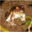

In [4]:
cifar10_train.data[0]

In [5]:
batch_size = 100
learning_rate = 0.01
training_epochs = 20
loss_function = nn.CrossEntropyLoss()
network = MLP()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)

data_loader = DataLoader(dataset=cifar10_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

In [6]:
network = network.to("cuda:0")
network.train()
for epoch in range(training_epochs):
    avg_cost = 0
    total_batch = len(data_loader)


    for img, label in data_loader:
        img = img.to("cuda:0")
        label = label.to("cuda:0")

        pred = network(img)

        loss = loss_function(pred, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_cost += loss / total_batch
    print('Epoch: %d, lr = %f, Loss = %f' %(epoch+1, optimizer.param_groups[0]['lr'], avg_cost))
print('Learning finished')

/tmp/ipykernel_5056/2687518744.py:20: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('Epoch: %d, lr = %f, Loss = %f' %(epoch+1, optimizer.param_groups[0]['lr'], avg_cost))


Epoch: 1, lr = 0.010000, Loss = 2.304515
Epoch: 2, lr = 0.010000, Loss = 2.303160
Epoch: 3, lr = 0.010000, Loss = 2.302766
Epoch: 4, lr = 0.010000, Loss = 2.302655
Epoch: 5, lr = 0.010000, Loss = 2.302619
Epoch: 6, lr = 0.010000, Loss = 2.302601
Epoch: 7, lr = 0.010000, Loss = 2.302583
Epoch: 8, lr = 0.010000, Loss = 2.302578
Epoch: 9, lr = 0.010000, Loss = 2.302572
Epoch: 10, lr = 0.010000, Loss = 2.302560
Epoch: 11, lr = 0.010000, Loss = 2.302559
Epoch: 12, lr = 0.010000, Loss = 2.302550
Epoch: 13, lr = 0.010000, Loss = 2.302538
Epoch: 14, lr = 0.010000, Loss = 2.302535
Epoch: 15, lr = 0.010000, Loss = 2.302523
Epoch: 16, lr = 0.010000, Loss = 2.302513
Epoch: 17, lr = 0.010000, Loss = 2.302504
Epoch: 18, lr = 0.010000, Loss = 2.302493
Epoch: 19, lr = 0.010000, Loss = 2.302480
Epoch: 20, lr = 0.010000, Loss = 2.302467
Learning finished


In [7]:
network = network.to("cpu")
network.eval()
with torch.no_grad(): # test에서는 기울기 계산 제외

  img_test = torch.tensor(np.transpose(cifar10_test.data,(0,3,1,2))) / 255.
  label_test = torch.tensor(cifar10_test.targets)

  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.10000000149011612
